# XGBoost placement prediction

This notebook runs the Phase 4 XGBoost model using the shared Phase 2 feature columns, target encoding, split, and scaling. It does not create a second dataset or split.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

PHASE4_DIR = Path.cwd()
PROJECT_DIR = PHASE4_DIR.parent
DATA_PATH = PROJECT_DIR / "student_placement_phase1_ready.xlsx"
RESULTS_PATH = PHASE4_DIR / "xgboost_results.csv"
IMPORTANCE_PATH = PHASE4_DIR / "xgboost_feature_importance.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Phase 1 dataset not found: {DATA_PATH}")

In [2]:
features = [
    "college_pursuing_year", "cgpa", "branch", "college_tier",
    "internships_count", "projects_count", "certifications_count",
    "coding_skill_score", "aptitude_score", "communication_skill_score",
    "logical_reasoning_score", "hackathons_participated", "github_repos",
    "mock_interview_score", "attendance_percentage", "backlogs",
    "extracurricular_score", "leadership_score", "volunteer_experience",
]

df = pd.read_excel(DATA_PATH)
X = pd.get_dummies(
    df[features],
    columns=["branch", "college_tier", "volunteer_experience"],
    drop_first=True,
).astype(float)
y = df["placement_status"].map({"Not Placed": 0, "Placed": 1})

phase2_features = X.columns.tolist()
if y.isna().any():
    raise ValueError("placement_status contains values outside the Phase 2 target encoding")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Match Phase 2 preprocessing exactly: fit only on training data.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [3]:
def evaluate(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "Model": "XGBoost",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
    }, y_pred, y_prob

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)
baseline_metrics, _, _ = evaluate(xgb_model)
pd.DataFrame([baseline_metrics])

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.56735,0.574218,0.789846,0.664989,0.581955


In [4]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 5],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1.0],
}


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
    ),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_
metrics, y_pred, y_prob = evaluate(best_xgb)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)
pd.DataFrame([metrics]).to_csv(RESULTS_PATH, index=False)
pd.DataFrame([metrics])

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
Best cross-validation F1-score: 0.6939341698212049


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.5624,0.559595,0.915847,0.694712,0.576305


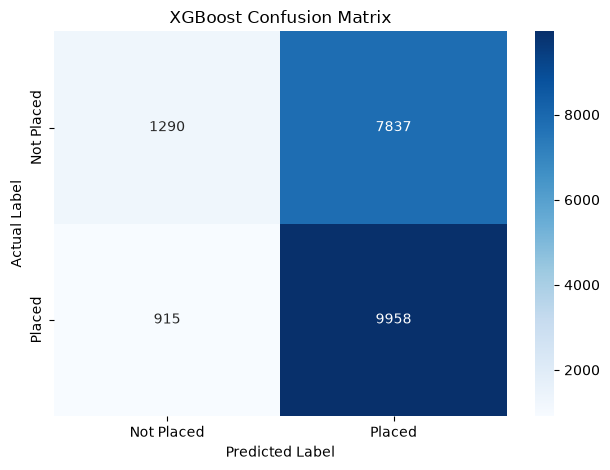

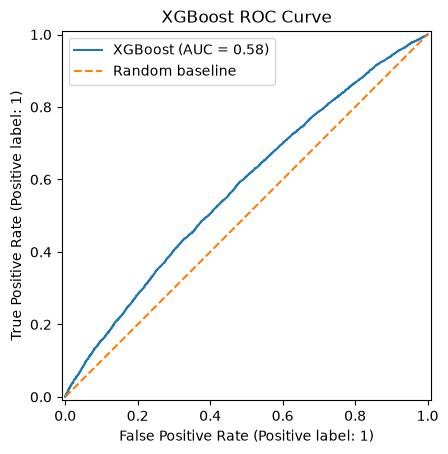

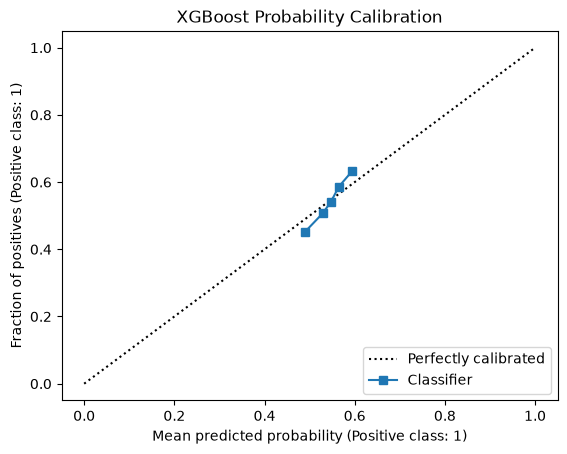

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"],
)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob, name="XGBoost")
plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()

CalibrationDisplay.from_predictions(y_test, y_prob, n_bins=5, strategy="quantile")
plt.title("XGBoost Probability Calibration")
plt.show()

In [7]:
importance = pd.DataFrame({
    "Feature": phase2_features,
    "Importance": best_xgb.feature_importances_,
}).sort_values("Importance", ascending=False)
importance.to_csv(IMPORTANCE_PATH, index=False)
importance.head(10)

,Feature,Importance
13,backlogs,0.236090
3,projects_count,0.123051
2,internships_count,0.121201
5,coding_skill_score,0.110851
11,mock_interview_score,0.095379
7,communication_skill_score,0.078199
8,logical_reasoning_score,0.073696
6,aptitude_score,0.071352
14,extracurricular_score,0.046315
15,leadership_score,0.043865
